<a href="https://colab.research.google.com/github/Gowrav06/Data-Science/blob/main/Data_Preprocessing_%26_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data handling
import pandas as pd
import numpy as np

In [2]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import IsolationForest

In [4]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [6]:
#Load the Dataset
df = pd.read_csv("adult_with_headers (1).csv")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
df.shape

(32561, 15)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [9]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [10]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [11]:
# Handling Missing Values
df.replace("?", np.nan, inplace=True)

df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [12]:
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

In [13]:
for col in df.select_dtypes(include=['int64','float64']):
    df[col].fillna(df[col].median(), inplace=True)

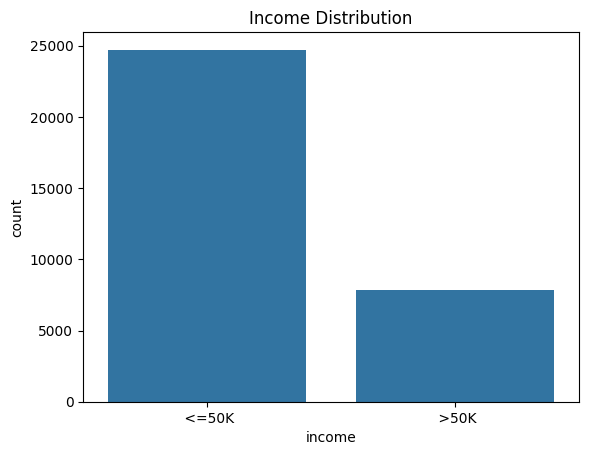

In [14]:
# Exploratory Data Analysis (EDA)
sns.countplot(x='income', data=df)
plt.title("Income Distribution")
plt.show()

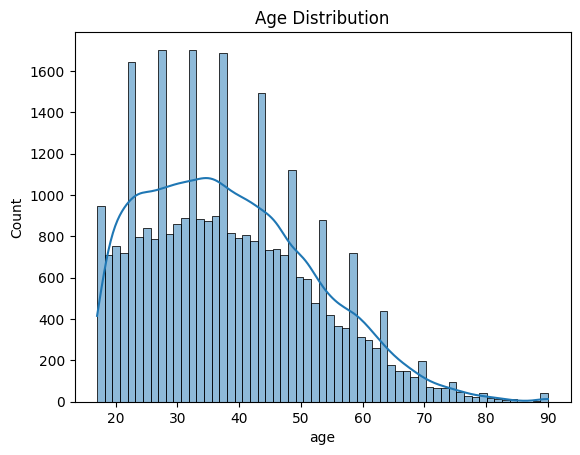

In [15]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

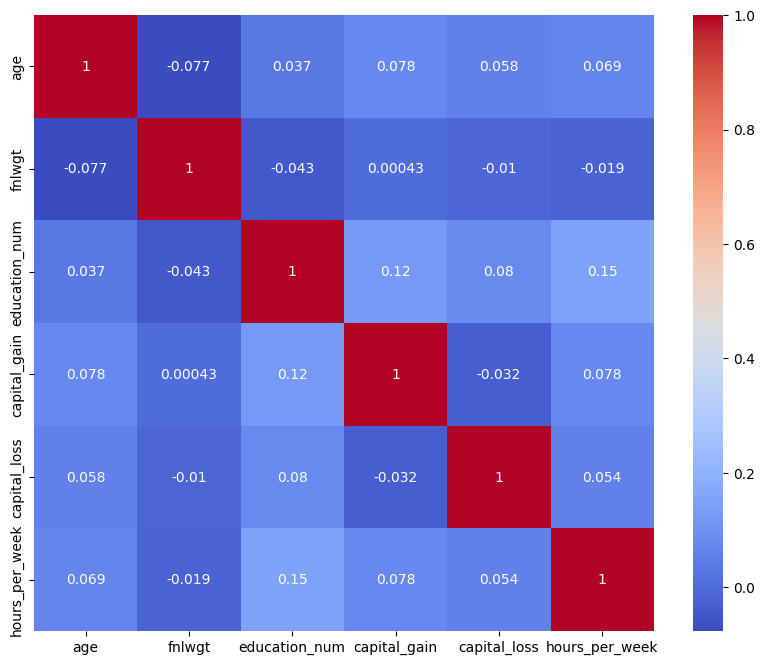

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

In [18]:
df = pd.get_dummies(df, columns=['sex'], drop_first=True)

In [19]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [21]:
# Feature Engineering
df['capital_ratio'] = df['capital_gain'] / (df['capital_loss'] + 1)

In [22]:
df['age_group'] = pd.cut(df['age'], bins=[0,25,40,60,100],
                         labels=['Young','Adult','Middle','Senior'])

In [23]:
df['age_group'] = LabelEncoder().fit_transform(df['age_group'])

In [25]:
df['capital_gain'].skew()

np.float64(11.953847687699799)

In [26]:
df['log_capital_gain'] = np.log1p(df['capital_gain'])

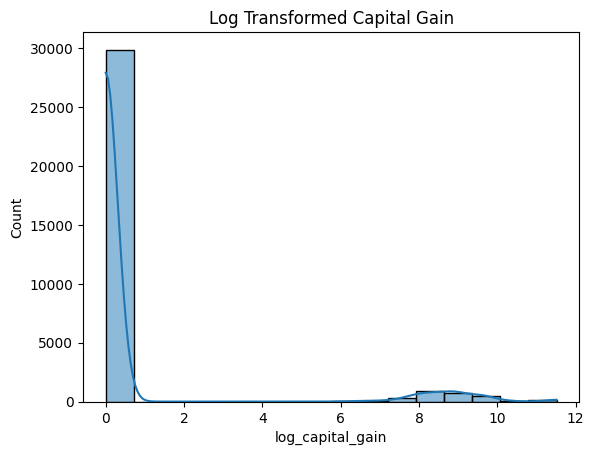

In [27]:
sns.histplot(df['log_capital_gain'], kde=True)
plt.title("Log Transformed Capital Gain")
plt.show()

In [28]:
scaler = StandardScaler()

num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

In [29]:
scaler = MinMaxScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

In [30]:
iso = IsolationForest(contamination=0.05)

outliers = iso.fit_predict(df)

df['outlier'] = outliers

In [31]:
df = df[df['outlier'] == 1]

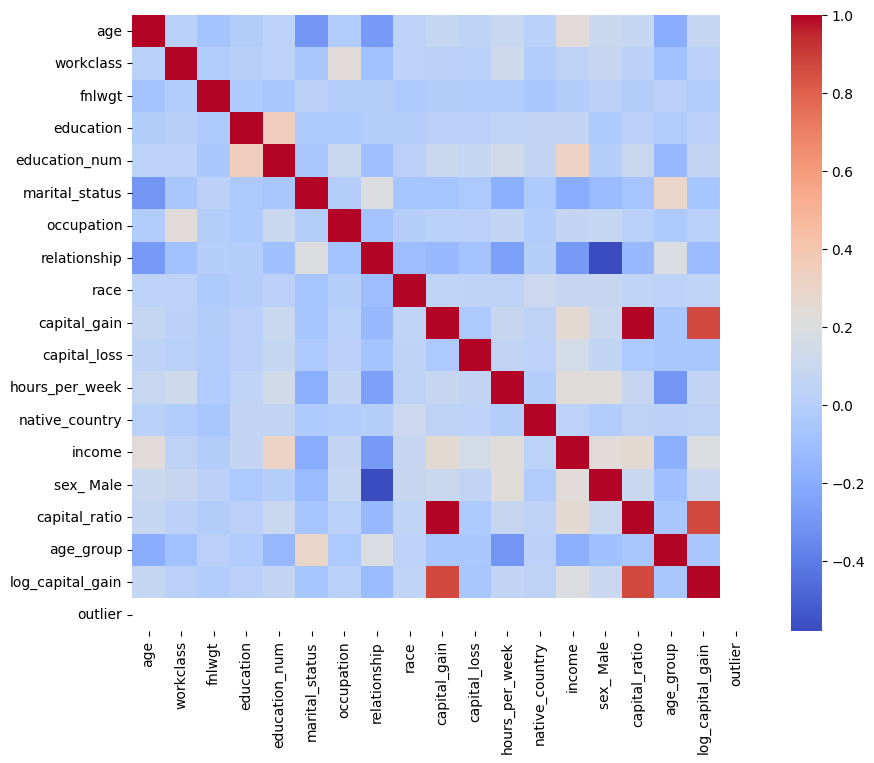

In [32]:
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [33]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_ Male,capital_ratio,age_group,log_capital_gain,outlier
0,0.301370,0.875,0.044302,0.600000,0.800000,0.666667,0.071429,0.2,1.0,0.02174,0.0,0.397959,0.951220,0.0,True,0.02174,0.000000,0.667492,1
1,0.452055,0.750,0.048238,0.600000,0.800000,0.333333,0.285714,0.0,1.0,0.00000,0.0,0.122449,0.951220,0.0,True,0.00000,0.333333,0.000000,1
2,0.287671,0.500,0.138113,0.733333,0.533333,0.000000,0.428571,0.2,1.0,0.00000,0.0,0.397959,0.951220,0.0,True,0.00000,0.000000,0.000000,1
3,0.493151,0.500,0.151068,0.066667,0.400000,0.333333,0.428571,0.0,0.5,0.00000,0.0,0.397959,0.951220,0.0,True,0.00000,0.333333,0.000000,1
4,0.150685,0.500,0.221488,0.600000,0.800000,0.333333,0.714286,1.0,0.5,0.00000,0.0,0.397959,0.121951,0.0,False,0.00000,0.000000,0.000000,1


In [34]:
df.to_csv("processed_adult_data.csv", index=False)